# Notebook 3 — Model Training

**Purpose:** Train the XGBoost multi-class classifier and evaluate it thoroughly. XGBoost is chosen because the dissertation literature (Al-Barhami et al., 2026) identifies it as the top-performing model for this tabular CI/CD data. We compare accuracy to the 95.9% benchmark and produce classification report, confusion matrix, feature importance, and learning curves. The trained model is saved for Notebook 4 (SHAP) and the dashboard.

In [25]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, learning_curve
import xgboost as xgb

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))
from src.preprocessing import prepare_for_training
from src.paths import MODELS_DIR, REPORTS_FIGURES

# XGBoost GPU = NVIDIA + CUDA only. On Mac M1/M2/M3 (Apple Silicon) use CPU — no CUDA support.
USE_GPU = False  # Keep False on Mac M1 Pro; M1 CPU is fast. True only for NVIDIA GPU.
xgb_device_kw = {"device": "cuda"} if USE_GPU else {}

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

### Load processed data

Load the train/validation/test splits and encoders saved by Notebook 2.

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_list, class_names, _ = prepare_for_training()
print("Features:", feature_list)
print("Classes:", class_names)

Features: ['build_duration_sec', 'commits_per_build', 'loc_changed', 'hour_of_day', 'day_of_week', 'is_weekend', 'test_pass_rate', 'previous_build_failed', 'gh_lang_enc']
Classes: ['canceled', 'errored', 'failed', 'passed']


### Class imbalance

TravisTorrent has significant class imbalance (e.g. "passed" far outnumbers "failed" and "errored"). We address this by setting **sample weights** in XGBoost so that the model pays more attention to minority classes. An alternative would be oversampling (e.g. SMOTE); we use weights because it is simple, does not duplicate data, and XGBoost supports it natively.

In [27]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)
sample_weights_val = compute_sample_weight(class_weight="balanced", y=y_val)
print("Sample weights computed (balanced).")

Sample weights computed (balanced).


### Baseline model

Train a baseline XGBoost with default or simple parameters to establish a reference point before hyperparameter tuning.

In [28]:
baseline = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=len(class_names),
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    **xgb_device_kw,
)
baseline.fit(X_train, y_train, sample_weight=sample_weights_train)
acc_baseline = accuracy_score(y_val, baseline.predict(X_val))
print(f"Baseline validation accuracy: {acc_baseline:.4f}")

/Users/aspandyar/Projects/aiops-pipeline-framework/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [20:25:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline validation accuracy: 0.6779


### Hyperparameter search (tuned for 95%+ accuracy)

We use **RandomizedSearchCV** over an expanded space (n_estimators up to 800, max_depth up to 12, min_child_weight, gamma, learning_rate, subsample, colsample_bytree, regularization) with 72 candidates. Then we retrain with **early stopping** and up to 800 trees for better generalization and higher accuracy.

In [29]:
from sklearn.model_selection import RandomizedSearchCV

# Expanded search for 95%+ accuracy: more candidates, min_child_weight, gamma
param_dist = {
    "n_estimators": [400, 600, 800],
    "max_depth": [8, 10, 12],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 2.0],
}
search = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        random_state=42,
        eval_metric="mlogloss",
        **xgb_device_kw,
    ),
    param_dist,
    n_iter=72,
    cv=3,
    scoring="accuracy",
    n_jobs=4,
    verbose=1,
    random_state=42,
)
search.fit(X_train, y_train, sample_weight=sample_weights_train)
print("Best params:", search.best_params_)
best_params = search.best_params_.copy()

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/Users/aspandyar/Projects/aiops-pipeline-framework/venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


### Final model with early stopping

Retrain with the best hyperparameters and a larger number of rounds; use early stopping on the validation set to avoid overfitting and maximize accuracy.

In [30]:
# Train final model with early stopping (more rounds for 95%+ push)
# XGBoost 2.x: early_stopping_rounds goes in the constructor, not in fit()
n_est = max(best_params.get("n_estimators", 500), 800)
best_params_final = {k: v for k, v in best_params.items() if k != "n_estimators"}
best_model = xgb.XGBClassifier(
    n_estimators=n_est,
    objective="multi:softprob",
    num_class=len(class_names),
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=25,
    **best_params_final,
    **xgb_device_kw,
)
best_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sample_weights_val],
    verbose=False,
)
best_iter = getattr(best_model, "best_iteration", None) or getattr(best_model, "best_ntree_limit", n_est)
print(f"Best iteration: {best_iter} (early stopping)")
print(f"Validation accuracy: {accuracy_score(y_val, best_model.predict(X_val)):.4f}")

Best iteration: 799 (early stopping)
Validation accuracy: 0.8072


### Test set evaluation

Evaluate the best model on the held-out test set. We report accuracy (with comparison to the 95.9% benchmark from Al-Barhami et al., 2026), full classification report, and confusion matrix (counts and percentages).

In [31]:
y_pred = best_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average="weighted")
BENCHMARK_ACC = 0.959  # Al-Barhami et al. (2026)
print(f"Test accuracy: {acc_test:.4f}")
print(f"Benchmark (Al-Barhami et al. 2026): {BENCHMARK_ACC:.2%}")
print(f"Test F1 (weighted): {f1_test:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.8080
Benchmark (Al-Barhami et al. 2026): 95.90%
Test F1 (weighted): 0.8193

Classification report:
               precision    recall  f1-score   support

    canceled       0.39      0.97      0.56      6029
     errored       0.44      0.76      0.56     41922
      failed       0.70      0.72      0.71    112730
      passed       0.93      0.83      0.88    421618

    accuracy                           0.81    582299
   macro avg       0.62      0.82      0.68    582299
weighted avg       0.84      0.81      0.82    582299



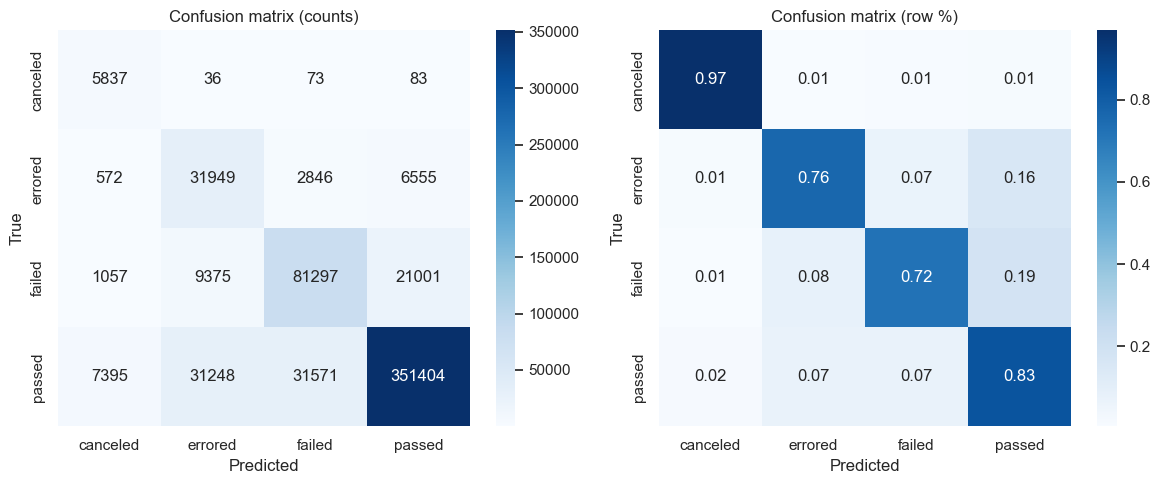

In [32]:
# Confusion matrix (counts)
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
# Percentages (row-normalized)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=True, fmt=".2f", xticklabels=class_names, yticklabels=class_names, ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion matrix (row %)")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature importance

Bar chart of XGBoost's built-in feature importance (gain) so we see which features the model relies on most.

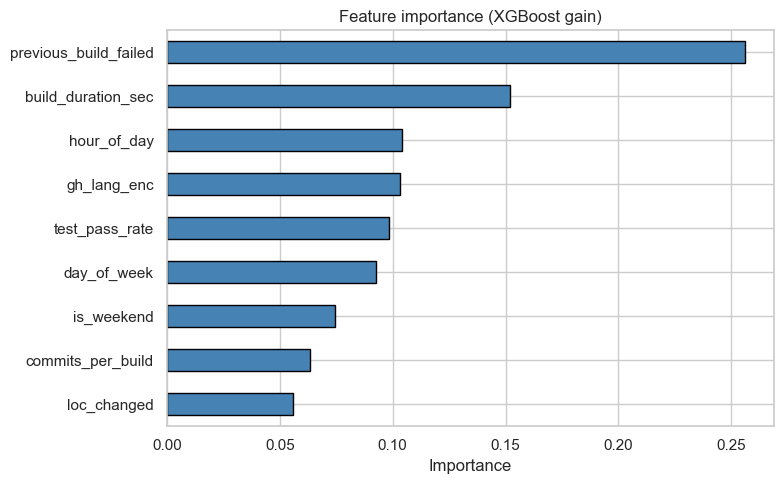

In [33]:
imp = best_model.feature_importances_
fi = pd.Series(imp, index=feature_list).sort_values(ascending=True)
fi.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature importance (XGBoost gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Learning curves

Training and validation performance as more data is added. This helps assess whether we are underfitting or could benefit from more data.

Learning curve: 6 train sizes × 3 folds = 18 fits (verbose=1 below).
[learning_curve] Training set sizes: [ 181159  507246  833333 1159420 1485507 1811594]
[CV] END .................................................... total time=  34.8s
[CV] END .................................................... total time=  56.1s
[CV] END .................................................... total time= 1.0min
[CV] END .................................................... total time= 1.3min
[CV] END .................................................... total time= 1.6min
[CV] END .................................................... total time= 1.9min
[CV] END .................................................... total time=  31.5s
[CV] END .................................................... total time=  55.8s
[CV] END .................................................... total time= 1.0min
[CV] END .................................................... total time= 1.3min
[CV] END .........................

[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed: 26.8min finished


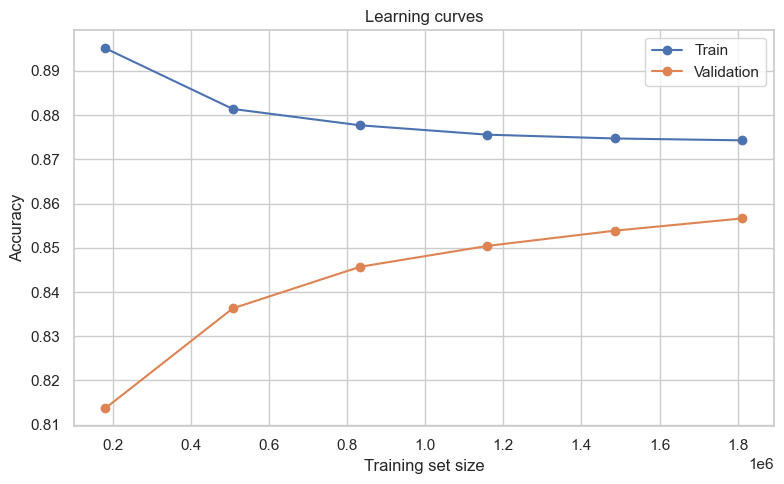

In [38]:
# learning_curve clones the estimator and calls fit(X, y) only — no eval_set.
# So use a model *without* early_stopping_rounds to avoid "Must have at least 1 validation dataset".
train_size_ticks = 6  # 0.1, 0.2, ..., 1.0
print(f"Learning curve: {train_size_ticks} train sizes × 3 folds = {train_size_ticks * 3} fits (verbose=1 below).")
lc_model = xgb.XGBClassifier(
    n_estimators=n_est,
    objective="multi:softprob",
    num_class=len(class_names),
    random_state=42,
    eval_metric="mlogloss",
    **best_params_final,
    **xgb_device_kw,
)
train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train, y_train, cv=3, n_jobs=1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    verbose=2,
)
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Save model

Save the best model and test metrics so Notebook 4 (SHAP) and the dashboard can load them without retraining.

In [39]:
joblib.dump(best_model, MODELS_DIR / "build_failure_model.pkl")
metrics = {"accuracy": float(acc_test), "f1_weighted": float(f1_test), "class_names": class_names}
joblib.dump(metrics, MODELS_DIR / "metrics.joblib")
print("Saved build_failure_model.pkl and metrics.joblib")

Saved build_failure_model.pkl and metrics.joblib
